# Projekt 4: Klasyfikacja obrazów liści (PlantVillage) — TensorFlow2/Keras

Zadania:
1. Wczytanie danych z Lab.3 (10 klas PlantVillage)
2. Budowa modeli Dense z różną liczbą warstw i neuronów
3. Wykresy loss i accuracy (trening vs walidacja) dla każdego modelu
4. Porównanie architektur

In [1]:
import os
import numpy as np
import cv2 as cv
from skimage import io as skio
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline

## 1. Wczytanie i przygotowanie danych z Lab.3

Używamy tych samych 10 klas z PlantVillage co w Lab.3. Obrazy skalowane do 64×64, normalizowane do [0,1].

In [2]:
IMG_SIZE = (64, 64)
MAX_PER_CLASS = 200
DATA_SRC = os.path.join('..', 'l3', 'data_src')

SELECTED_CLASSES = sorted([
    d for d in os.listdir(DATA_SRC)
    if os.path.isdir(os.path.join(DATA_SRC, d))
])
print(f"Klasy ({len(SELECTED_CLASSES)}):")
for c in SELECTED_CLASSES:
    n = len(os.listdir(os.path.join(DATA_SRC, c)))
    print(f"  {c}: {n} obrazów")
print(f"\nDo eksperymentów użyjemy maksymalnie {MAX_PER_CLASS} obrazów na klasę.")

Klasy (10):
  Apple___Apple_scab: 630 obrazów
  Apple___Black_rot: 621 obrazów
  Apple___healthy: 1645 obrazów
  Corn_(maize)___Common_rust_: 1192 obrazów
  Corn_(maize)___healthy: 1162 obrazów
  Grape___Black_rot: 1180 obrazów
  Grape___healthy: 423 obrazów
  Pepper,_bell___Bacterial_spot: 997 obrazów
  Pepper,_bell___healthy: 1478 obrazów
  Tomato___healthy: 1591 obrazów

Do eksperymentów użyjemy maksymalnie 200 obrazów na klasę.


In [3]:
def load_images(container_dir, classes, img_size=(64, 64), max_per_class=200, seed=42, max_error_report=10):
    """Wczytuje obrazy, losuje próbkę plików i normalizuje dane do [0,1]."""
    images = []
    labels = []
    failed_images = []
    rng = np.random.default_rng(seed)

    for cls in classes:
        cls_path = os.path.join(container_dir, cls)
        files = [
            fname for fname in os.listdir(cls_path)
            if os.path.isfile(os.path.join(cls_path, fname))
        ]
        files = sorted(files)
        rng.shuffle(files)
        files = files[:max_per_class]

        loaded_for_class = 0
        failed_for_class = 0

        for fname in files:
            fpath = os.path.join(cls_path, fname)
            try:
                img = skio.imread(fpath)
                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)
                if img.ndim == 3 and img.shape[2] == 4:
                    img = img[:, :, :3]
                if img.ndim != 3 or img.shape[2] != 3:
                    raise ValueError(f'Nieoczekiwany kształt obrazu: {img.shape}')

                img = cv.resize(img, img_size, interpolation=cv.INTER_AREA)
                images.append(img)
                labels.append(cls)
                loaded_for_class += 1
            except Exception as exc:
                failed_for_class += 1
                failed_images.append((fpath, str(exc)))

        if loaded_for_class == 0:
            raise RuntimeError(f'Nie udało się wczytać żadnego obrazu dla klasy {cls}.')

        print(f'  {cls}: wczytano {loaded_for_class} obrazów, pominięto {failed_for_class}')

    images = np.array(images, dtype=np.float32) / 255.0

    if failed_images:
        print(f'\nPominięto łącznie {len(failed_images)} obrazów z powodu błędów.')
        for fpath, message in failed_images[:max_error_report]:
            print(f'  {fpath}: {message}')
        if len(failed_images) > max_error_report:
            print(f'  ... oraz {len(failed_images) - max_error_report} kolejnych błędów')

    return images, labels

all_images, all_labels = load_images(
    DATA_SRC,
    SELECTED_CLASSES,
    IMG_SIZE,
    max_per_class=MAX_PER_CLASS,
    seed=42,
)

le = LabelEncoder()
le.fit(SELECTED_CLASSES)
all_y = le.transform(all_labels)
num_classes = len(le.classes_)

print(f"\nŁącznie: {len(all_y)} obrazów, {num_classes} klas")
print(f"Wymiar obrazów: {all_images.shape}")

  Apple___Apple_scab: wczytano 200 obrazów, pominięto 0
  Apple___Black_rot: wczytano 200 obrazów, pominięto 0
  Apple___healthy: wczytano 200 obrazów, pominięto 0
  Corn_(maize)___Common_rust_: wczytano 200 obrazów, pominięto 0
  Corn_(maize)___healthy: wczytano 200 obrazów, pominięto 0
  Grape___Black_rot: wczytano 200 obrazów, pominięto 0
  Grape___healthy: wczytano 200 obrazów, pominięto 0
  Pepper,_bell___Bacterial_spot: wczytano 200 obrazów, pominięto 0
  Pepper,_bell___healthy: wczytano 200 obrazów, pominięto 0
  Tomato___healthy: wczytano 200 obrazów, pominięto 0

Łącznie: 2000 obrazów, 10 klas
Wymiar obrazów: (2000, 64, 64, 3)


In [4]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    all_images, all_y, test_size=0.15, random_state=42, stratify=all_y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 ≈ 0.15/0.85
)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Wymiar jednego obrazu: {X_train.shape[1:]}")

# Spłaszczenie dla modeli Dense
input_dim = X_train.shape[1] * X_train.shape[2] * X_train.shape[3]
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Input dim (spłaszczony): {input_dim}")

Train: 1400, Val: 300, Test: 300
Wymiar jednego obrazu: (64, 64, 3)
Input dim (spłaszczony): 12288


## 2. Definicja architektur modeli


In [5]:
def build_model(hidden_layers, input_dim, num_classes, name="model"):
    """Buduje model Sequential z podanymi warstwami ukrytymi."""
    model = keras.Sequential(name=name)
    model.add(layers.Input(shape=(input_dim,)))
    
    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(units, activation='relu', name=f'dense_{i}'))
    
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Definicje architektur
architectures = {
    'A: [32]':               [32],
    'B: [64, 32]':           [64, 32],
    'C: [128, 64]':          [128, 64],
    'D: [256, 128, 64]':     [256, 128, 64],
    'E: [512, 256, 128, 64]': [512, 256, 128, 64],
    'F: [128, 128, 64]':     [128, 128, 64],
    'G: [256, 128]':         [256, 128],
    'H: [512, 256, 128]':    [512, 256, 128],
}

# Podgląd struktury modeli
for name, hidden in architectures.items():
    model = build_model(hidden, input_dim, num_classes, name=name.split(':')[0])
    total_params = model.count_params()
    print(f"{name:30s} — parametry: {total_params:>10,}")
    del model

A: [32]                        — parametry:    393,578
B: [64, 32]                    — parametry:    788,906
C: [128, 64]                   — parametry:  1,581,898
D: [256, 128, 64]              — parametry:  3,187,786
E: [512, 256, 128, 64]         — parametry:  6,465,098
F: [128, 128, 64]              — parametry:  1,598,410
G: [256, 128]                  — parametry:  3,180,170
H: [512, 256, 128]             — parametry:  6,457,482


## 3. Trenowanie modeli i zapis historii

Każdy model trenowany jest z walidacją, pomiarem metryk na zbiorze testowym po każdej epoce oraz logowaniem do TensorBoard. Najlepszy model wybieramy wyłącznie na podstawie walidacyjnego `loss`, aby nie używać zbioru testowego do selekcji architektury.

In [6]:
import shutil

EPOCHS = 30
BATCH_SIZE = 32
LOG_DIR = os.path.join('logs', 'fit')

class TestMetricsCallback(keras.callbacks.Callback):
    def __init__(self, test_data):
        super().__init__()
        self.test_x, self.test_y = test_data
        self.test_loss = []
        self.test_accuracy = []

    def on_epoch_end(self, epoch, logs=None):
        loss, accuracy = self.model.evaluate(self.test_x, self.test_y, verbose=0)
        self.test_loss.append(loss)
        self.test_accuracy.append(accuracy)

histories = {}
test_results = {}

if os.path.exists(LOG_DIR):
    shutil.rmtree(LOG_DIR)
os.makedirs(LOG_DIR, exist_ok=True)

for arch_name, hidden in architectures.items():
    print(f"\n{'=' * 60}")
    print(f"Trenowanie: {arch_name}")
    print(f"{'=' * 60}")

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_model(hidden, input_dim, num_classes, name=arch_name.split(':')[0])

    arch_log_dir = os.path.join(LOG_DIR, arch_name.split(':')[0])
    test_callback = TestMetricsCallback((X_test_flat, y_test))
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
    )
    tensorboard_callback = keras.callbacks.TensorBoard(
        log_dir=arch_log_dir,
        histogram_freq=1,
        write_graph=True,
    )

    history = model.fit(
        X_train_flat,
        y_train,
        validation_data=(X_val_flat, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=[test_callback, early_stopping, tensorboard_callback],
    )

    final_test_loss, final_test_acc = model.evaluate(X_test_flat, y_test, verbose=0)

    hist = dict(history.history)
    hist['test_loss'] = test_callback.test_loss
    hist['test_accuracy'] = test_callback.test_accuracy
    histories[arch_name] = hist

    best_epoch_idx = int(np.argmin(hist['val_loss']))
    best_epoch = best_epoch_idx + 1
    best_val_loss = float(hist['val_loss'][best_epoch_idx])
    best_val_acc = float(hist['val_accuracy'][best_epoch_idx])

    test_results[arch_name] = {
        'best_epoch': best_epoch,
        'val_loss': best_val_loss,
        'val_accuracy': best_val_acc,
        'test_loss': float(final_test_loss),
        'test_accuracy': float(final_test_acc),
        'epochs_ran': len(hist['loss']),
        'log_dir': arch_log_dir,
    }

    print(
        f"  Best epoch: {best_epoch}, "
        f"Val loss: {best_val_loss:.4f}, "
        f"Val acc: {best_val_acc:.4f}, "
        f"Test acc: {final_test_acc:.4f}"
    )

BEST_MODEL_NAME = min(
    test_results,
    key=lambda name: (test_results[name]['val_loss'], -test_results[name]['val_accuracy']),
)
BEST_LOG_DIR = test_results[BEST_MODEL_NAME]['log_dir']

print("\nTrenowanie zakończone.")
print(f"Najlepszy model wg validation loss: {BEST_MODEL_NAME}")


Trenowanie: A: [32]
  Best epoch: 10, Val loss: 1.4008, Val acc: 0.5067, Test acc: 0.4867

Trenowanie: B: [64, 32]
  Best epoch: 11, Val loss: 0.8436, Val acc: 0.6700, Test acc: 0.7267

Trenowanie: C: [128, 64]
  Best epoch: 13, Val loss: 0.6512, Val acc: 0.7500, Test acc: 0.7833

Trenowanie: D: [256, 128, 64]
  Best epoch: 9, Val loss: 0.6972, Val acc: 0.7567, Test acc: 0.7400

Trenowanie: E: [512, 256, 128, 64]
  Best epoch: 15, Val loss: 0.7272, Val acc: 0.7367, Test acc: 0.7833

Trenowanie: F: [128, 128, 64]
  Best epoch: 10, Val loss: 0.7230, Val acc: 0.7300, Test acc: 0.7500

Trenowanie: G: [256, 128]
  Best epoch: 11, Val loss: 0.7433, Val acc: 0.7300, Test acc: 0.7633

Trenowanie: H: [512, 256, 128]
  Best epoch: 10, Val loss: 0.7676, Val acc: 0.7267, Test acc: 0.7167

Trenowanie zakończone.
Najlepszy model wg validation loss: C: [128, 64]


## 4. Wykresy loss i accuracy — walidacja vs test

Dla każdego modelu pokazujemy na wspólnym wykresie przebieg metryk na zbiorze walidacyjnym i testowym względem epok, zgodnie z wymaganiem zadania.

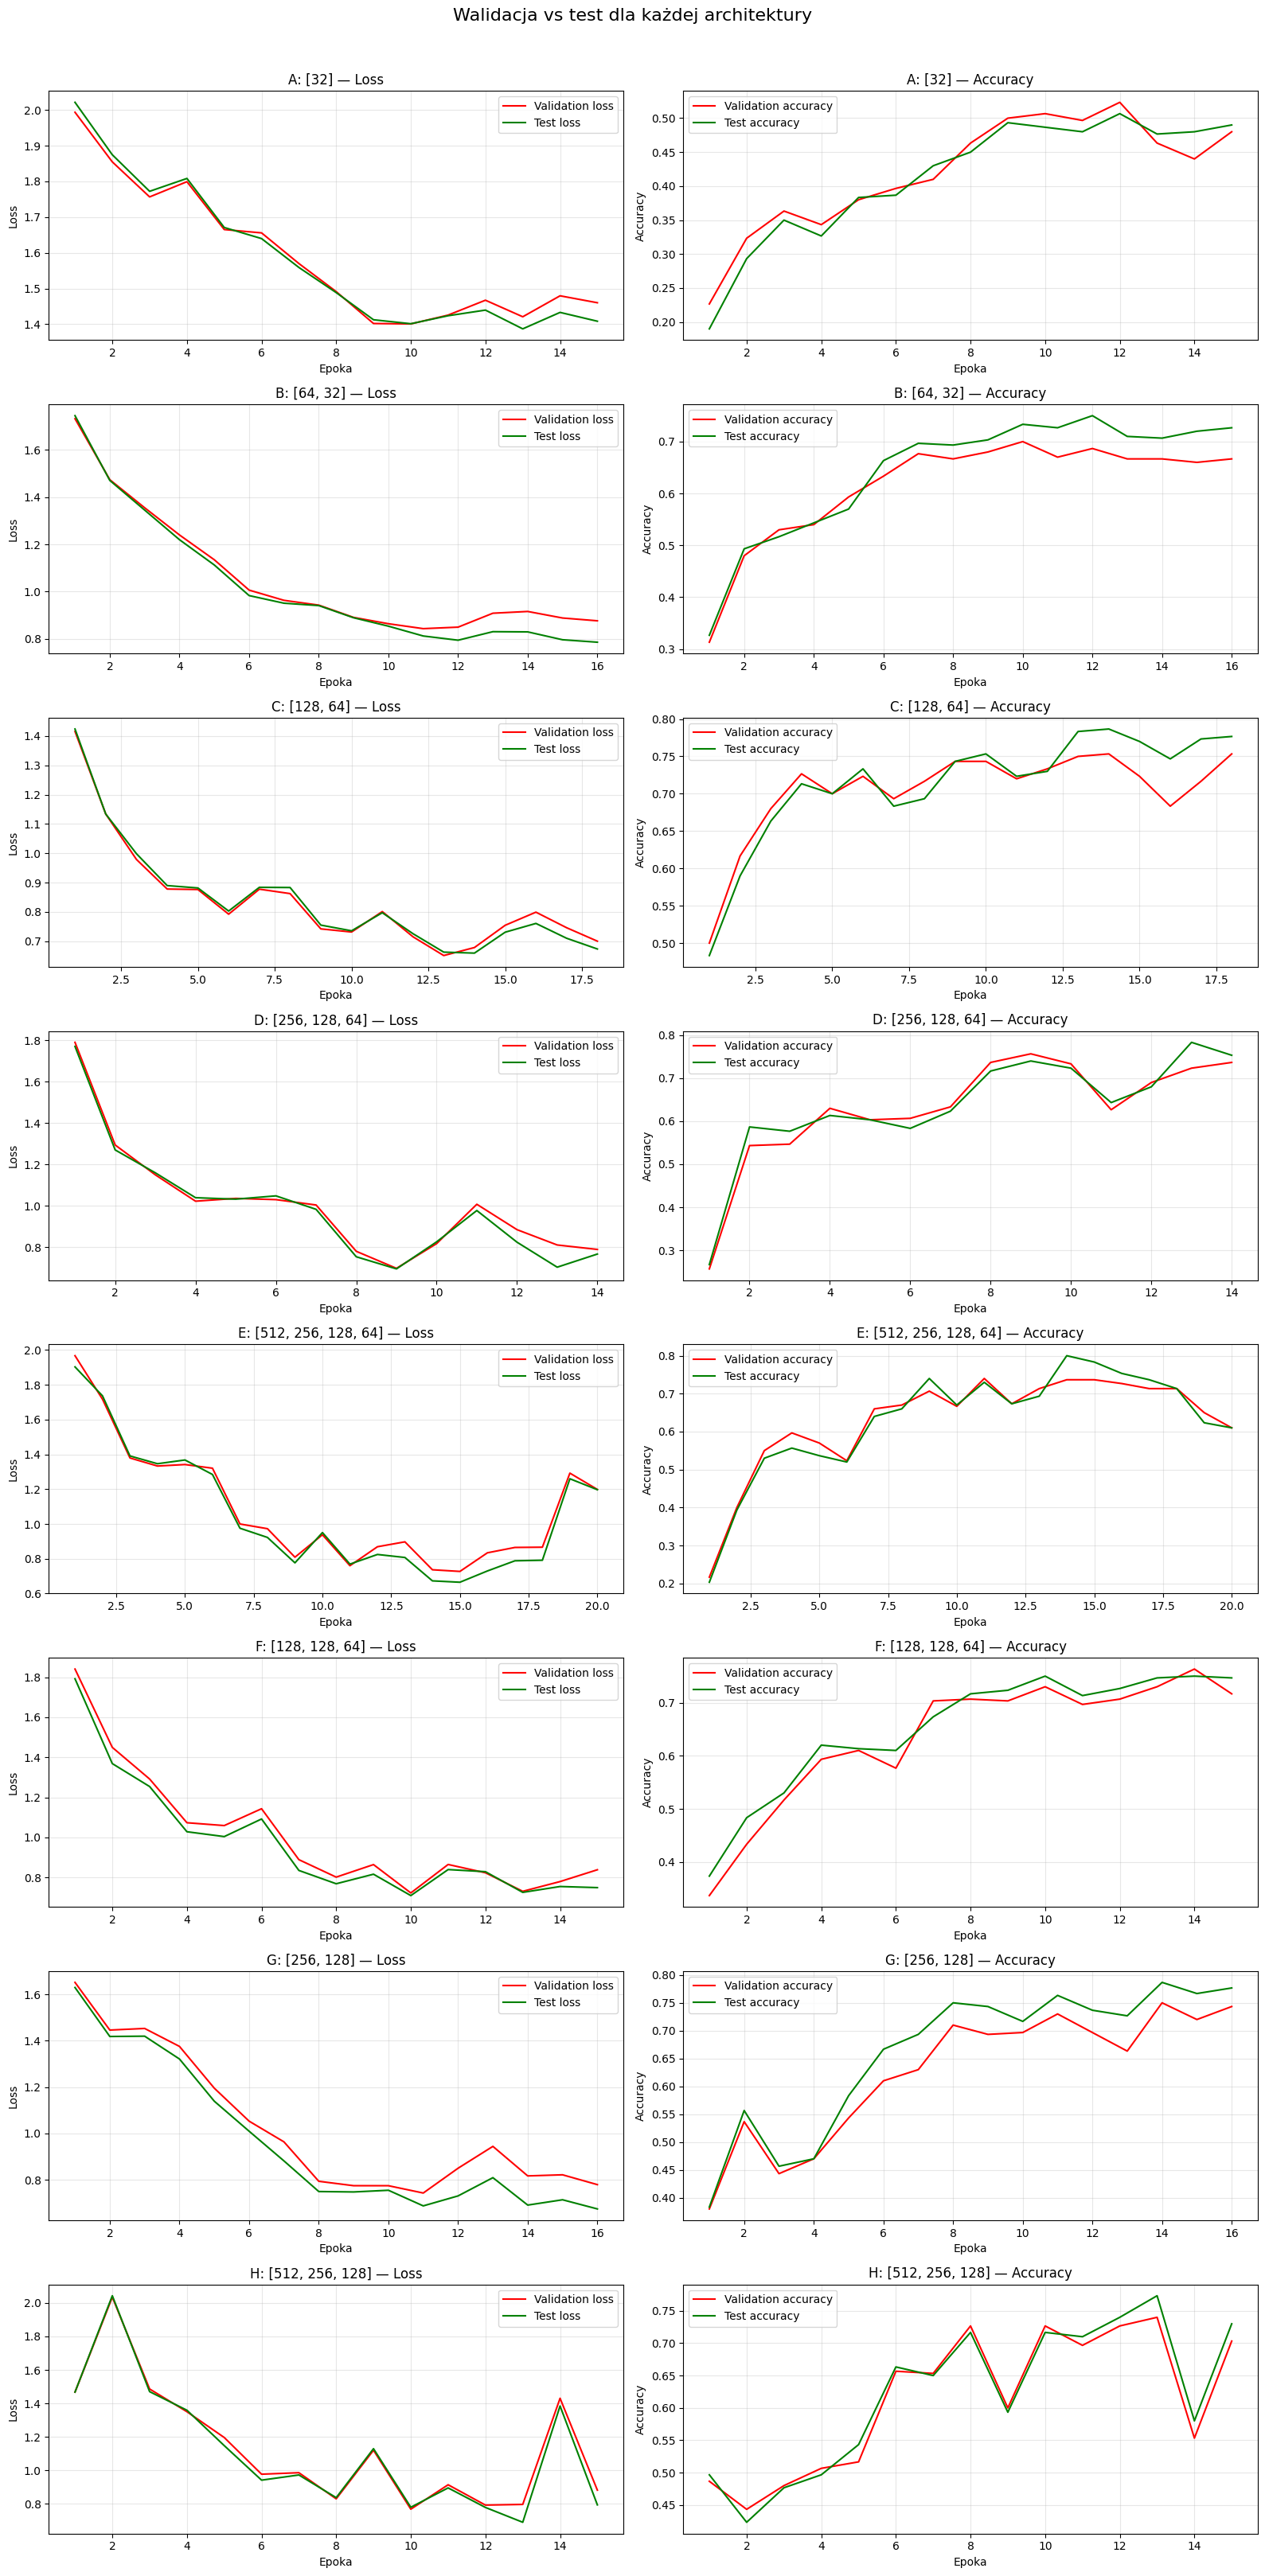

In [7]:
fig, axes = plt.subplots(len(architectures), 2, figsize=(16, 4 * len(architectures)))
if len(architectures) == 1:
    axes = np.array([axes])

for row, (arch_name, hist) in enumerate(histories.items()):
    epochs_range = range(1, len(hist['val_loss']) + 1)

    ax_loss = axes[row, 0]
    ax_loss.plot(epochs_range, hist['val_loss'], 'r-', label='Validation loss')
    ax_loss.plot(epochs_range, hist['test_loss'], 'g-', label='Test loss')
    ax_loss.set_title(f'{arch_name} — Loss')
    ax_loss.set_xlabel('Epoka')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[row, 1]
    ax_acc.plot(epochs_range, hist['val_accuracy'], 'r-', label='Validation accuracy')
    ax_acc.plot(epochs_range, hist['test_accuracy'], 'g-', label='Test accuracy')
    ax_acc.set_title(f'{arch_name} — Accuracy')
    ax_acc.set_xlabel('Epoka')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

plt.suptitle('Walidacja vs test dla każdej architektury', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 5. Porównanie wszystkich architektur

Na wspólnych wykresach porównujemy przebieg metryk walidacyjnych i testowych dla wszystkich modeli.

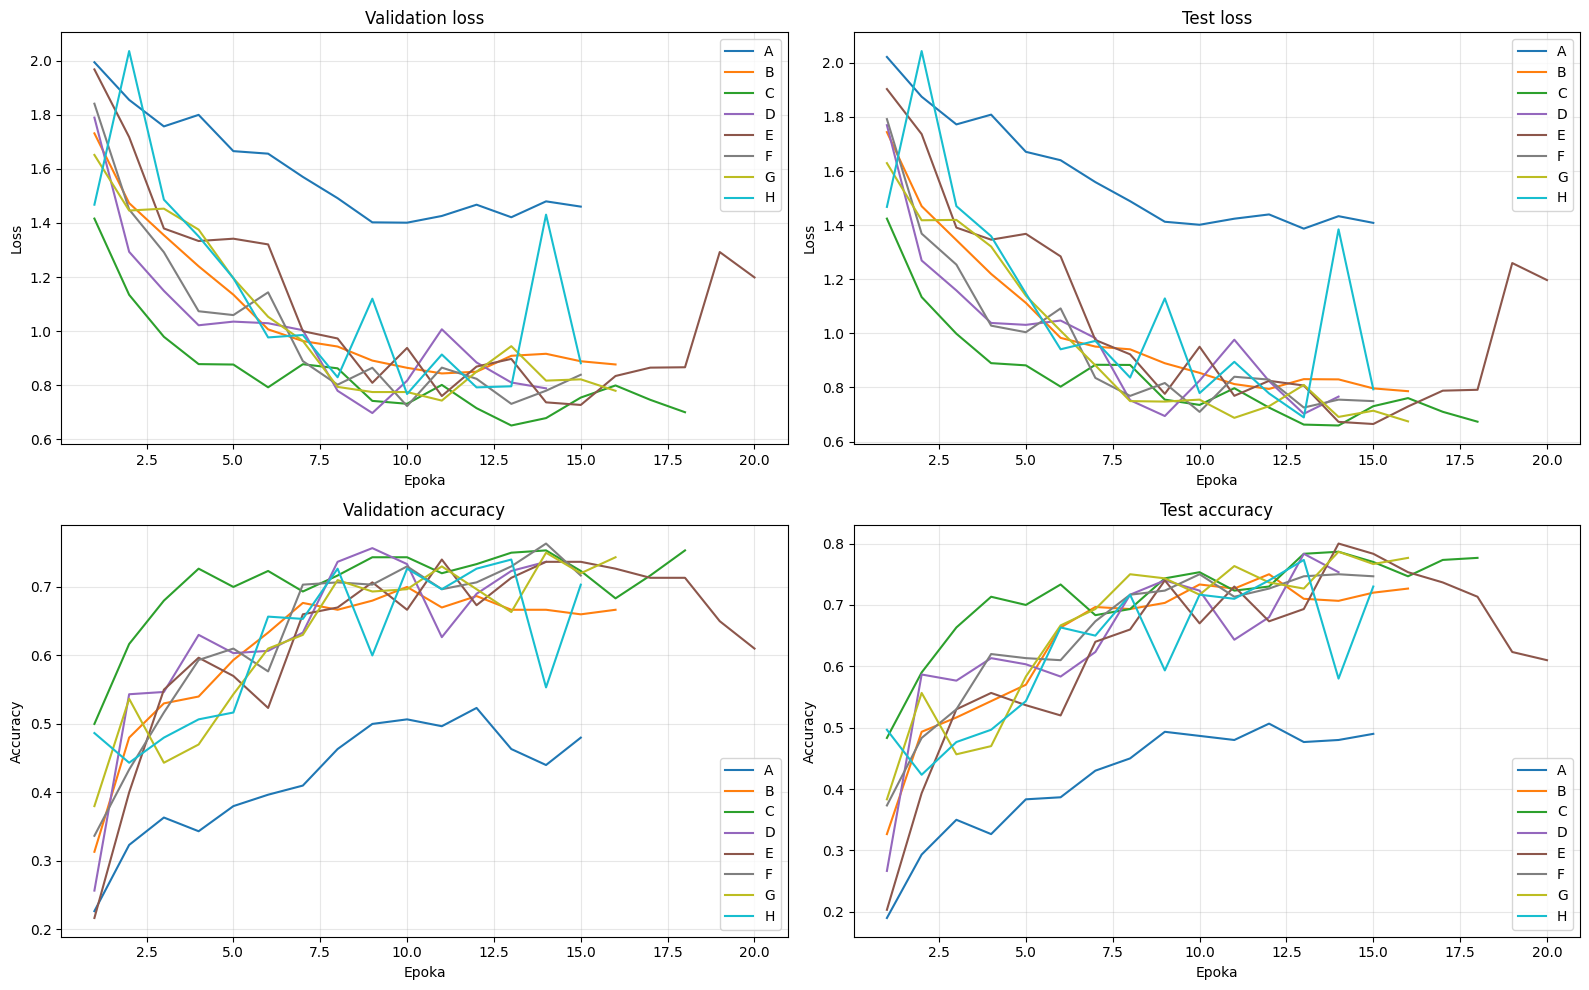

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = plt.cm.tab10(np.linspace(0, 1, len(architectures)))

for (arch_name, hist), color in zip(histories.items(), colors):
    epochs_range = range(1, len(hist['val_loss']) + 1)
    short = arch_name.split(':')[0]
    axes[0, 0].plot(epochs_range, hist['val_loss'], color=color, label=short)
    axes[0, 1].plot(epochs_range, hist['test_loss'], color=color, label=short)
    axes[1, 0].plot(epochs_range, hist['val_accuracy'], color=color, label=short)
    axes[1, 1].plot(epochs_range, hist['test_accuracy'], color=color, label=short)

axes[0, 0].set_title('Validation loss')
axes[0, 1].set_title('Test loss')
axes[1, 0].set_title('Validation accuracy')
axes[1, 1].set_title('Test accuracy')

for ax in axes.flatten():
    ax.set_xlabel('Epoka')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0, 0].set_ylabel('Loss')
axes[0, 1].set_ylabel('Loss')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

## 6. TensorBoard dla najlepszego modelu

Logi TensorBoard pochodzą bezpośrednio z oryginalnego treningu wszystkich architektur. Najlepszy model wybieramy według walidacyjnego `loss`, a następnie wskazujemy katalog z jego logami.

In [9]:
if not os.path.isdir(BEST_LOG_DIR):
    raise FileNotFoundError(f'Brak logów TensorBoard dla modelu {BEST_MODEL_NAME}: {BEST_LOG_DIR}')

print(f'Najlepszy model wg validation loss: {BEST_MODEL_NAME}')
print(f'Najlepsza epoka: {test_results[BEST_MODEL_NAME]["best_epoch"]}')
print(f'Validation loss: {test_results[BEST_MODEL_NAME]["val_loss"]:.4f}')
print(f'Validation accuracy: {test_results[BEST_MODEL_NAME]["val_accuracy"]:.4f}')
print(f'Test accuracy: {test_results[BEST_MODEL_NAME]["test_accuracy"]:.4f}')
print(f'Logi TensorBoard zapisano do: {BEST_LOG_DIR}')
print(f'Aby uruchomić TensorBoard w terminalu: tensorboard --logdir {LOG_DIR}')

Najlepszy model wg validation loss: C: [128, 64]
Najlepsza epoka: 13
Validation loss: 0.6512
Validation accuracy: 0.7500
Test accuracy: 0.7833
Logi TensorBoard zapisano do: logs/fit/C
Aby uruchomić TensorBoard w terminalu: tensorboard --logdir logs/fit


## 7. Podsumowanie wyników

In [10]:
print(f"{'Model':<30} | {'Best ep.':>8} | {'Val Acc':>8} | {'Val Loss':>9} | {'Test Acc':>8} | {'Test Loss':>9}")
print('-' * 88)

for arch_name, res in test_results.items():
    print(
        f"{arch_name:<30} | "
        f"{res['best_epoch']:>8} | "
        f"{res['val_accuracy']:>8.4f} | "
        f"{res['val_loss']:>9.4f} | "
        f"{res['test_accuracy']:>8.4f} | "
        f"{res['test_loss']:>9.4f}"
    )

print('-' * 88)
print(f"\nNajlepszy model według validation loss: {BEST_MODEL_NAME}")
print(f"Najlepsza epoka: {test_results[BEST_MODEL_NAME]['best_epoch']}")
print(f"Validation loss: {test_results[BEST_MODEL_NAME]['val_loss']:.4f}")
print(f"Validation accuracy: {test_results[BEST_MODEL_NAME]['val_accuracy']:.4f}")
print(f"Test loss: {test_results[BEST_MODEL_NAME]['test_loss']:.4f}")
print(f"Test accuracy: {test_results[BEST_MODEL_NAME]['test_accuracy']:.4f}")
print(f"Rozmiar obrazu: {IMG_SIZE}")
print(f"Liczba klas: {num_classes}")
print(f"Dane: train={X_train.shape[0]}, val={X_val.shape[0]}, test={X_test.shape[0]}")
print(f"Epoki: {EPOCHS}, Batch size: {BATCH_SIZE}")

Model                          | Best ep. |  Val Acc |  Val Loss | Test Acc | Test Loss
----------------------------------------------------------------------------------------
A: [32]                        |       10 |   0.5067 |    1.4008 |   0.4867 |    1.4014
B: [64, 32]                    |       11 |   0.6700 |    0.8436 |   0.7267 |    0.8126
C: [128, 64]                   |       13 |   0.7500 |    0.6512 |   0.7833 |    0.6629
D: [256, 128, 64]              |        9 |   0.7567 |    0.6972 |   0.7400 |    0.6945
E: [512, 256, 128, 64]         |       15 |   0.7367 |    0.7272 |   0.7833 |    0.6650
F: [128, 128, 64]              |       10 |   0.7300 |    0.7230 |   0.7500 |    0.7099
G: [256, 128]                  |       11 |   0.7300 |    0.7433 |   0.7633 |    0.6879
H: [512, 256, 128]             |       10 |   0.7267 |    0.7676 |   0.7167 |    0.7792
----------------------------------------------------------------------------------------

Najlepszy model według valida

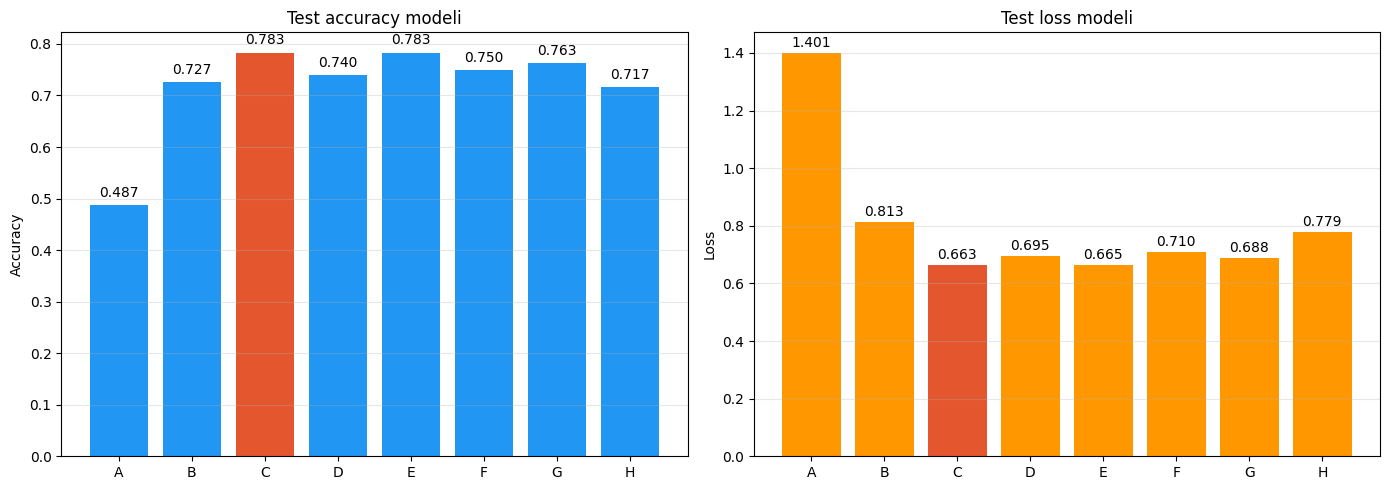

In [11]:
model_names = list(test_results.keys())
short_names = [name.split(':')[0] for name in model_names]
accs = [test_results[name]['test_accuracy'] for name in model_names]
losses = [test_results[name]['test_loss'] for name in model_names]
acc_colors = ['#E4572E' if name == BEST_MODEL_NAME else '#2196F3' for name in model_names]
loss_colors = ['#E4572E' if name == BEST_MODEL_NAME else '#FF9800' for name in model_names]

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(short_names))

bars_acc = ax_acc.bar(x, accs, color=acc_colors)
for bar, val in zip(bars_acc, accs):
    ax_acc.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
    )
ax_acc.set_title('Test accuracy modeli')
ax_acc.set_ylabel('Accuracy')
ax_acc.set_xticks(x)
ax_acc.set_xticklabels(short_names)
ax_acc.grid(True, alpha=0.3, axis='y')

bars_loss = ax_loss.bar(x, losses, color=loss_colors)
for bar, val in zip(bars_loss, losses):
    ax_loss.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
    )
ax_loss.set_title('Test loss modeli')
ax_loss.set_ylabel('Loss')
ax_loss.set_xticks(x)
ax_loss.set_xticklabels(short_names)
ax_loss.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()